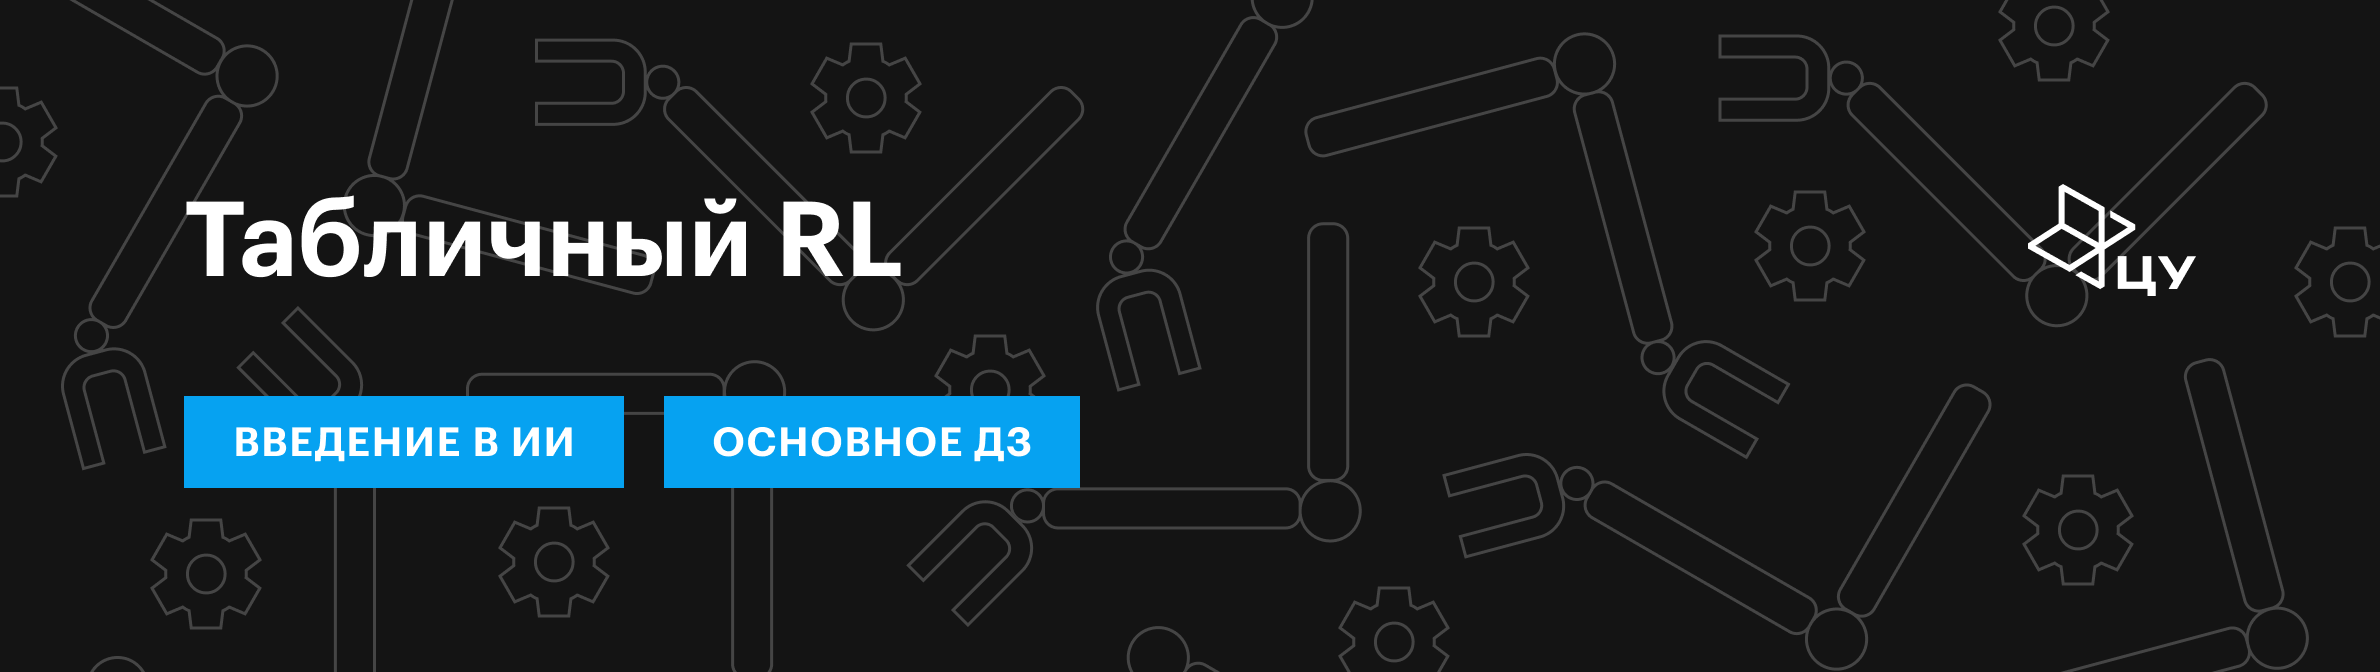

# Домашнее задание по теме «Табличный RL»

В этом домашнем задании ты реализуешь табличные RL-алгоритмы:
- напишешь свою дискретную среду `gymnasium.Env`;
- реализуешь TD(λ) для оценки $V$-функции;
- реализуешь Q-learning для оценки $Q$-функции.

>### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.

## Импорт пакетов

In [102]:
# Тут будут все необходимые импорты

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

## Задание 1 [2 балла]

Создай среду (табличный MDP) и проведи тесты.

1) Реализуй среду `MyTabularEnv(gym.Env)`:
   - реализуй методы `reset()` и `step()`;
   - задай `observation_space` и `action_space` как `spaces.Discrete`.
2) В комментариях к классу явно укажи:
   - где старт, `Goal` и `Hole` — их можно задавать через индексы состояний;
   - как устроены награды.
3) Проведи два теста корректности реализации:
   - на корректность — `reset/step`;
   - о завершении эпизода — встречается `terminated` или `truncated`.

>**Правила начисления баллов:**
>- реализован корректный интерфейс Gymnasium, задано описание MDP — **[1 балл]**;
>- реализованы 2 теста — **[1 балл]**.


**Описание среды**

| Элемент таблицы | Описание |
|--------------|------------------|
| Поле  | `H×W` (возьми минимум `5×5`)  |
| Состояние `s`  | Одно число `0 ... nS - 1`, соответствующее клетке `(row,column)`  |
| Действия `a` (4)  | `0 = up, 1 = right, 2 = down, 3 = left` |
| Динамика  | Действие двигает на 1 клетку, действия не могут выводить за пределы таблицы (например, если стоим вверху таблицы <br> и идём вверх, то просто остаёмся на месте, чтобы не выйти за границы)  |
| Терминальные состояния  | `Goal` — успешная клетка и `Hole` — дыра, попав в которую, умираем |
| Награды  | Например, каждый шаг: `-0.01`, `Goal`: `+1.0`, `Hole`: `-1.0`  |
| Окончание эпизода  | `terminated = True` при попадании в `Goal` или `Hole`, или `truncated = True`, если превышен `max_steps`  |

**Требования к реализации среды**
| Требование | Описание |
|--------------|------------------|
| Рекомендуемый размер множеств  | `nS ≤ 100`, `nA` небольшой (4–6)  |
| Дискретные пространства  | `observation_space = Discrete(nS)`, `action_space = Discrete(nA)`  |
| Хранение значений в табличных массивах  | `V[nS]`, `Q[nS,nA]` (без нейросетей) |
| Завершение эпизодов  | `terminated` или `truncated`  |

> **Примечание:**
>- `nS` – размерность множества состояний;
>- `na` – размерность множества действий.

In [103]:
class MyTabularEnv(gym.Env):
    """
    GridWorld H x W (табличка)
    Состояние s: int в [0, nS)
    Координаты можно получать так
      r = s // width
      c = s % width
    """

    def __init__(self, height=5, width=5, max_steps=50):
        assert height > 0 and width > 0, "height и width должны быть положительными"
        assert max_steps > 0, "max_steps должен быть положительным"

        self.height = height
        self.width = width

        self.nS = height * width
        self.nA = 4

        self.max_steps = max_steps

        self.observation_space = spaces.Discrete(self.nS)
        self.action_space = spaces.Discrete(self.nA)

        # Настройка карты
        self.start_s = 0
        self.goal_s = self.nS - 1
        self.holes = np.random.randint(1, self.nS - 2, size=3).tolist()
        self.walls = np.random.randint(1, self.nS - 2, size=3).tolist()

        # Настройка наград
        self.step_reward = -0.01
        self.goal_reward = 1
        self.hole_reward = -1

        # Полезные проверки
        assert self.nA == 4, "ожидается 4 действия: up/right/down/left"
        assert 0 <= self.start_s < self.nS, "start_s вне диапазона состояний"
        assert 0 <= self.goal_s < self.nS, "goal_s вне диапазона состояний"
        assert self.start_s != self.goal_s, "start_s и goal_s не должны совпадать"

        for h in self.holes:
            assert 0 <= h < self.nS, f"hole {h} вне диапазона состояний"
        for w in self.walls:
            assert 0 <= w < self.nS, f"wall {w} вне диапазона состояний"

        assert self.start_s not in self.holes, "start_s не должен быть дыркой"
        assert self.goal_s not in self.holes, "goal_s не должен быть дыркой"

        self._t = 0
        self._state = self.start_s

    def is_goal(self, s: int) -> bool:
        """Вернёт True, если s – успешная клетка"""

        # Полезные проверки
        assert 0 <= s < self.nS, "s вне диапазона состояний"

        return s == self.goal_s

    def is_hole(self, s: int) -> bool:
        """Вернёт True, если s – дырка"""

        # TODO
        # Вернуть True только в случае, когда состояние s является дыркой

        # Полезные проверки
        assert 0 <= s < self.nS, "s вне диапазона состояний"

        return s in self.holes

    def is_terminal(self, s: int) -> bool:
        """Вернёт True, если состояние s терминальное"""

        # TODO
        # Использовать is_goal(...) и is_hole(...),
        # чтобы определить, является ли состояние терминальным

        # Полезные проверки
        assert 0 <= s < self.nS, "s вне диапазона состояний"

        return self.is_goal(s) or self.is_hole(s)

    def _next_state_deterministic(self, s: int, a: int) -> int:
        """
        Детерминированный переход по действию
        Подсказка:
        - r = s // width; c = s % width
        - (dr,dc) для действий up/right/down/left
        - проверка границ; проверка walls (если используешь)
        - если при действии выходим за границы таблицы, остаёмся в s
        """

        # TODO
        # 1. Перевести s в координаты (r, c)
        # 2. Определить смещение (dr, dc) по действию a
        # 3. Посчитать кандидата в следующую клетку
        # 4. Если выходим за границы, остаться в s
        # 5. Если упираемся в стену, остаться в s
        # 6. Вернуть индекс следующего состояния ns

        # Полезные проверки
        assert 0 <= s < self.nS, "некорректное состояние s"
        assert 0 <= a < self.nA, "некорректное действие a"

        r = s // self.width
        c = s % self.width

        act = {
            0: [-1, 0],
            1: [0, 1],
            2: [1, 0],
            3: [0, -1],
        }

        dr = r + act[a][0]
        dc = c + act[a][1]

        if not (0 <= dr < self.height and 0 <= dc < self.width):
            return s
        ns = dr * self.width + dc
        if ns in self.walls:
            return s
        return ns

    def _reward(self, s: int, a: int, ns: int) -> float:
        """Награда за переход"""

        # TODO
        # 1. Если ns является goal, вернуть goal_reward
        # 2. Если ns является hole, вернуть hole_reward
        # 3. Иначе вернуть step_reward

        # Полезные проверки
        assert 0 <= s < self.nS, "s вне диапазона состояний"
        assert 0 <= a < self.nA, "a вне диапазона действий"
        assert 0 <= ns < self.nS, "ns вне диапазона состояний"

        if self.is_goal(ns):
          return self.goal_reward
        if self.is_hole(ns):
          return self.hole_reward
        return self.step_reward

    def reset(self, seed=None, options=None):
        """Reset уже реализован"""
        super().reset(seed=seed)
        self._t = 0
        self._state = self.start_s
        return self._state, {}

    def step(self, action: int):
        """Делаем шаг в среде: (obs, reward, terminated, truncated, info)"""

        # TODO
        # 1. Проверить, что action допустимо
        # 2. Вычислить следующее состояние ns
        # 3. Посчитать reward
        # 4. Обновить self._state и self._t
        # 5. Определить terminated и truncated
        # 6. Вернуть (obs, reward, terminated, truncated, info)

        # Полезные проверки
        assert self.action_space.contains(action), "action вне action_space"

        ns = self._next_state_deterministic(self._state, action)
        reward = self._reward(self._state, action, ns)
        self._state = ns
        self._t += 1
        is_term = self.is_terminal(self._state)
        is_trunc = self._t >= self.max_steps

        return (self._state, reward, is_term, is_trunc, {})

Проверь себя. Если твоя реализация проходит тесты ниже, то всё ок.

In [104]:
env = MyTabularEnv(height = 4, width = 4, max_steps = 20)

# Базовые свойства
assert env.nS == 16
assert env.nA == 4

# reset
obs, info = env.reset()
assert obs == env.start_s
assert isinstance(info, dict)

# Терминальная логика
assert env.is_goal(env.goal_s) is True
assert env.is_terminal(env.goal_s) is True

for h in env.holes:
    assert env.is_hole(h) is True
    assert env.is_terminal(h) is True

# Границы: из левого верхнего угла вверх и влево остаемся на месте
assert env._next_state_deterministic(0, 0) == 0   # up
assert env._next_state_deterministic(0, 3) == 0   # left

# Формат step
obs, reward, terminated, truncated, info = env.step(1)
assert 0 <= obs < env.nS
assert isinstance(reward, (int, float))
assert isinstance(terminated, bool)
assert isinstance(truncated, bool)
assert isinstance(info, dict)

print("Всё окей")

Всё окей


## Задание 2. [2 балла]

Реализуй фиксированную политику и генерацию траекторий.

1) Задай случайную baseline политику $\pi$. Например, `uniform`.
2) Реализуй генерацию одного эпизода — код должен возвращать список переходов `(s, a, r, s_next, done)`.
3) Посчитай статистику по `N` эпизодам:
   - среднюю длину;
   - среднюю сумму наград (без дисконта).

>**Правила начисления баллов:**
>- реализована и применена корректная baseline политика — **[1 балл]**;
>- реализована корректная генерация эпизода и сбор статистики — **[1 балл]**.


In [105]:
def make_baseline_policy(nA: int):
    """Реализация твоей baseline-политики"""

    assert nA > 0

    def policy(s: int) -> int:

        a = np.random.randint(0, nA)
        assert 0 <= a < nA, "policy вернула некорректное действие"
        return a

    return policy

In [106]:
def rollout_episode(env: gym.Env, policy, max_steps: int = 50):
    """
    Сгенерировать эпизод
    Вернуть list[(s, a, r, next_state, done)]
    """
    assert max_steps > 0

    episode = []
    s, _ = env.reset()

    for _ in range(max_steps):
        # TODO
        # 1. Выбери действие a = policy(s)
        # 2. Сделай шаг в среде
        # 3. Собери transition = (s, a, r, next_state, done)
        # 4. Добавь transition в episode
        # 5. Обнови s
        # 6. Если done, заверши эпизод

        a = policy(s)
        transition = env.step(a)
        episode.append(transition)
        obs, r, terminated, truncated, info = transition
        next_state = obs
        done = terminated or truncated

        s = next_state

        # Полезные проверки
        assert 0 <= a < env.action_space.n
        assert 0 <= next_state < env.observation_space.n
        assert isinstance(r, (int, float))
        assert isinstance(done, bool)
        assert len(transition) == 5

        if done:
          break

    assert isinstance(episode, list)
    return episode

In [107]:
def rollout_stats(env: gym.Env, policy, n_episodes: int = 10):
    """
    Функция для вывода статистики по эпизодам
    Вернуть (mean_len, mean_sum_reward)
    """
    assert n_episodes > 0

    lengths, returns = list(), list()

    for _ in range(n_episodes):
        ep = rollout_episode(env, policy)
        lengths.append(len(ep))
        rew_sum = 0
        for i in ep:
          rew_sum += i[1]
        returns.append(rew_sum)

        # Полезные проверки
        assert isinstance(ep, list)

        pass

    # TODO
    mean_len = sum(lengths) / len(lengths)
    mean_sum_reward = sum(returns) / len(returns)
    # 4. Посчитай mean_len и mean_sum_reward

    # Полезные проверки
    assert isinstance(mean_len, (int, float, np.floating))
    assert isinstance(mean_sum_reward, (int, float, np.floating))

    return mean_len, mean_sum_reward

## Задание 3. [3 балла]

Реализуй `TD(λ)` для фиксированной baseline-политики из задания 2.

1) Сгенерируй эпизод (траекторию) под фиксированной baseline политикой.
2) Для каждого шага `t`, посчитай **λ-return** $G^{\lambda}$ (см. функцию ниже).
3) Обнови табличную оценку V под фиксированной baseline-политикой:
    $$ V(s_t) \to \alpha \cdot (G^{\lambda_t} - V(s_t))$$

>**Правила начисления баллов:**
>- корректно реализованы: метод `TD(λ)` и обновления V — **[2 балла]**;
>- метрики залогированы и выведен результат — **[1 балл]**.

In [108]:
def n_step_return(rewards, gamma: float, t: int, n: int) -> float:
    """
    Посчитать n-step return G_t^(n) по массиву rewards
    rewards[k] = r_k (на шаге k)

    Подсказка
    G = sum_{i = 0}^{n - 1} gamma^i * r_{t + i}
    """

    # TODO


    # 1. Проверь, сколько шагов осталось до конца эпизода
    # 2. Аккуратно просуммируй rewards[t], rewards[t+1], ..., rewards[t+n-1]
    # 3. Верни полученное значение

    # Полезные проверки
    assert 0 <= gamma <= 1, "обычно gamma берут в [0, 1]"
    assert 0 <= t < len(rewards), "t должен указывать на существующий шаг эпизода"
    assert n > 0, "n должно быть положительным"
    assert t + n <= len(rewards), "для n-step return нельзя выходить за границы rewards"

    return sum(gamma**i * rewards[t + i] for i in range(n))

In [109]:
def lambda_return(rewards, gamma: float, lambda_: float, t: int) -> float:
    """
    Посчитать λ-return G_t^λ для конечного эпизода

    Подсказка

    - Пусть T = len(rewards) (число шагов до done)

    - Вспоминаем формулу с лекции: смешиваем n-step returns:
      G^λ_t = (1 - λ) * sum_{n = 1}^{T - t - 1} λ^(n-1) * G_t^(n) + λ^(T - t - 1) * G_t^(T - t)
    """

    # TODO
    # 1. Определи длину хвоста эпизода от момента t до конца
    # 2. Для всех нужных n посчитай G_t^(n) через n_step_return(...)
    # 3. Собери λ-return по формуле
    # 4. Верни итоговое значение

    # Полезные проверки
    assert 0 <= gamma <= 1, "обычно gamma берут в [0, 1]"
    assert 0 <= lambda_ <= 1, "lambda должно быть в [0, 1]"
    assert 0 <= t < len(rewards), "t должен указывать на существующий шаг эпизода"
    assert len(rewards) > 0, "эпизод не должен быть пустым"

    T = len(rewards)
    max_n = T - t

    weighted_sum = 0.0
    for n in range(1, max_n):
        g_n = n_step_return(rewards, gamma, t, n)
        weighted_sum += (lambda_ ** (n - 1)) * g_n
    g_lambda = (1 - lambda_) * weighted_sum

    g_last = n_step_return(rewards, gamma, t, max_n)
    g_lambda += (lambda_ ** (max_n - 1)) * g_last

    return g_lambda

In [110]:
def td_lambda_policy_evaluation_forward(
    env: MyTabularEnv,
    policy,
    gamma: float,
    alpha: float,
    lambda_: float,
    num_episodes: int,
):
    """
    TD(λ) через λ-return

    Подсказка

    1. V = zeros(nS)

    2. Для каждого эпизода
       - собрать transitions = rollout_episode(...)
       - достать rewards и states: s_t
       - для каждого t:
           G_lam = lambda_return(rewards, gamma, lambda_, t)
           V[s_t] += alpha * (G_lam - V[s_t])
    3. Выводить логирование метрики (например: средний |G_lam - V[s_t]| по t)
    """

    # TODO
    # 1. Инициализируй табличную value-функцию V
    # 2. Запусти цикл по эпизодам
    # 3. В каждом эпизоде получи transitions = rollout_episode(...)
    # 4. Достань из transitions список rewards и список states
    # 5. Для каждого шага t:
    #       - посчитай G_lam
    #       - обнови V[s_t]
    #       - при желании сохрани метрику ошибки
    # 6. Верни V (и при желании историю метрик)

    # Полезные проверки
    assert env.nS > 0, "в среде должно быть хотя бы одно состояние"
    assert 0 <= gamma <= 1, "обычно gamma берут в [0, 1]"
    assert 0 <= lambda_ <= 1, "lambda должно быть в [0, 1]"
    assert alpha > 0, "alpha должно быть положительным"
    assert num_episodes > 0, "число эпизодов должно быть положительным"

    V = np.zeros(env.nS)
    metric_log = []

    for ep in range(num_episodes):
        transitions = rollout_episode(env, policy)

        states  = [tr[0] for tr in transitions]
        rewards = [tr[1] for tr in transitions]

        episode_errors = []

        for t in range(len(states)):
            s_t = states[t]

            G_lam = lambda_return(rewards, gamma, lambda_, t)

            td_error = G_lam - V[s_t]
            V[s_t] += alpha * td_error

            episode_errors.append(abs(td_error))

        mean_err = np.mean(episode_errors)
        metric_log.append(mean_err)
    return V, metric_log

In [111]:
def plot_metric(metric_log, title="TD(λ): Средняя абсолютная TD-ошибка по эпизодам"):
    plt.plot(metric_log, color='tab:blue', linewidth=1.5)

    plt.xlabel('Номер эпизода', fontsize=12)
    plt.ylabel('Mean |G^λ - V(s_t)|', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

## Задание 4. [3 балла]

Реализуй табличный Q-learning и сравни его качество с baseline-политикой.

1) Реализуй Q-learning с $\epsilon$-greedy-политикой:
   - храни значения в таблице `Q[s,a]`;
   - обновляй значения по правилу `Q[s,a] += α*(target - Q[s,a])`;
   - используй `target = r` если done, иначе — `r + γ*max_a' Q[s',a']`.
2) Построй greedy policy из `Q`-функции.
3) Оцени greedy vs baseline по дисконтированному вознаграждению (discounted return).

>**Правила начисления баллов:**
>- реализован корректный Q-learning и $\epsilon$-greedy — **[2 балла]**;
>- есть сравнение политик, а также краткий вывод — **[1 балл]**.


In [112]:
def epsilon_greedy_action(Q: np.ndarray, s: int, eps: float) -> int:
    """epsilon — жадный выбор действия"""

    # TODO
    # 1. С вероятностью eps, выбрать случайное действие.
    # 2. Иначе, выбрать argmax по Q[s].

    # Полезные проверки
    assert Q.ndim == 2, "Q должна быть матрицей shape = (nS, nA)"
    assert 0 <= s < Q.shape[0], "некорректный индекс состояния s"
    assert 0 <= eps <= 1, "eps должно быть в [0, 1]"

    if np.random.uniform(0, 1) < eps:
      return np.random.randint(0, Q.shape[1])
    else:
      return np.argmax(Q[s])

In [113]:
def q_learning(
    env: MyTabularEnv,
    gamma: float,
    alpha: float,
    eps: float,
    num_episodes: int,
):
    """
    Табличный Q-learning
    Возврат: Q, rewards_log (например, sum reward per episode)
    """

    # TODO
    # 1. Инициализируй Q нулями shape = (env.nS, env.nA)
    # 2. Заведи rewards_log
    # 3. Для каждого эпизода:
    #       - reset среды
    #       - крутить шаги до done
    #       - выбрать действие через epsilon_greedy_action(...)
    #       - сделать шаг в среде
    #       - посчитать target:
    #             если done: target = r
    #             иначе:     target = r + gamma * max_a' Q[s_next, a']
    #       - обновить Q[s, a]
    #       - накопить reward за эпизод
    # 4. Верни Q, rewards_log

    # Полезные проверки
    assert env.nS > 0 and env.nA > 0, "в среде должны быть состояния и действия"
    assert 0 <= gamma <= 1, "gamma должно быть в [0, 1]"
    assert alpha > 0, "alpha должно быть положительным"
    assert 0 <= eps <= 1, "eps должно быть в [0, 1]"
    assert num_episodes > 0, "число эпизодов должно быть положительным"

    Q = np.zeros((env.nS, env.nA))
    rewards_log = []

    for ep in range(num_episodes):
        s, _ = env.reset()
        done = False

        ep_reward = 0

        while not done:
            action = epsilon_greedy_action(Q, s, eps)
            obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc

            if done:
              target = reward
            else:
              target = reward + gamma * np.max(Q[obs])
            Q[s, action] += alpha * (target - Q[s, action])
            s = obs
            ep_reward += reward
        rewards_log.append(ep_reward)
    return Q, rewards_log

In [114]:
def greedy_policy_from_Q(Q: np.ndarray):
    """
    Жадный выбор действия по Q: policy(s) -> argmax_a Q[s,a]
    """

    # Полезные проверки
    assert Q.ndim == 2, "Q должна быть матрицей shape = (nS, nA)"

    def policy(s: int) -> int:
        # TODO
        # Верни индекс действия с максимальным Q[s, a]

        # Полезные проверки
        assert 0 <= s < Q.shape[0], "некорректный индекс состояния s"

        action = np.argmax(Q[s])
        return action

    return policy

In [115]:
def discounted_return_episode(env: gym.Env, policy, gamma: float, max_steps: int = 50) -> float:
    """Запускает один эпизод по заданной политике и возвращает discounted return"""

    # TODO
    # 1. Выполни reset среды
    # 2. Запусти эпизод по policy
    # 3. Аккуратно посчитай discounted return:
    #       G = r_1 + gamma * r_2 + gamma^2 * r_3 + ...
    # 4. Верни G

    # Полезные проверки
    assert 0 <= gamma <= 1, "gamma должно быть в [0, 1]"
    assert max_steps > 0, "max_steps должно быть положительным"

    s, _ = env.reset()
    transitions = rollout_episode(env, policy, max_steps)
    rewards = [tr[1] for tr in transitions]
    G = 0.0
    for i, r in enumerate(rewards):
      G += gamma ** i * r
    return G

In [116]:
def evaluate_policy(env: gym.Env, policy, gamma: float, n_episodes: int = 5):
    """
    Запускает много эпизодов (аргумент n_episodes) и считает статистику качества политики
    Стастика – например, пара (mean, std)
    """

    # TODO
    # 1. Много раз вызови discounted_return_episode(...)
    # 2. Собери returns
    # 3. Посчитай mean и std
    # 4. Верни mean и std

    # Полезные проверки
    assert n_episodes > 0, "число эпизодов должно быть положительным"
    assert 0 <= gamma <= 1, "gamma должно быть в [0, 1]"

    G_s = np.array([discounted_return_episode(env, policy, gamma) for i in range(n_episodes)])
    return G_s.mean(), G_s.std()

In [117]:
def compare_policies(env: gym.Env, gamma: float, learned_policy, baseline_policy):
    """Сравнивает learned policy vs baseline, выводит результат"""

    # TODO
    # 1. Оцени learned_policy
    # 2. Оцени baseline_policy
    # 3. Выведи результаты в понятном виде

    # Полезные проверки
    assert 0 <= gamma <= 1, "gamma должно быть в [0, 1]"

    mean_l, std_l = evaluate_policy(env, learned_policy, gamma, 50)
    mean_b, std_b = evaluate_policy(env, baseline_policy, gamma, 50)

    print(f"{'Baseline':<15} | {mean_b:<15.3f} | {std_b:<15.3f}")
    print(f"{'Learned (Q)':<15} | {mean_l:<15.3f} | {std_l:<15.3f}")



In [120]:
Q, log = q_learning(env, gamma=0.95, alpha=0.1, eps=0.1, num_episodes=2000)

learned_policy = greedy_policy_from_Q(Q)
baseline_policy = make_baseline_policy(4)

compare_policies(env, gamma=0.95, learned_policy=learned_policy, baseline_policy=baseline_policy)

Baseline        | -0.855          | 0.231          
Learned (Q)     | 0.729           | 0.000          


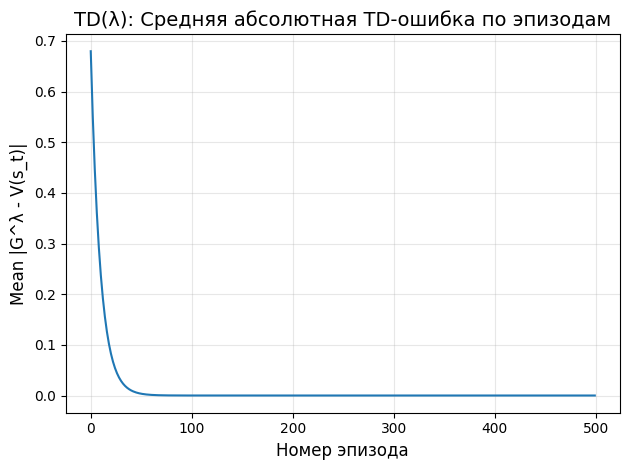

In [121]:
V, metric = td_lambda_policy_evaluation_forward(env, learned_policy, 0.95, 0.1, 0.9, 500)
plot_metric(metric)

ну вроде что-то получилось, но все равно ничо не понятно :( живем живем
